# Instalacion e importacion de librerias

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Librerias importadas correctamente.')

Librerias importadas correctamente.


# Carga del Dataset

In [44]:
path = "/content/drive/MyDrive/ModeladoPredictivo2026/data/WELFake_Dataset.csv"

In [45]:
df = pd.read_csv(path)

In [46]:
df.head(3)

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1


In [47]:
df.tail(3)

,Unnamed: 0,title,text,label
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0
72133,72133,Goldman Sachs Endorses Hillary Clinton For Pre...,Goldman Sachs Endorses Hillary Clinton For Pre...,1


In [48]:
df.drop([
    "Unnamed: 0",
], axis=1, inplace=True)

In [49]:
print(df["label"].unique())

[1 0]


In [50]:
class_names = {0: 'Fake', 1: 'Real'}

In [51]:
print(f'Forma del dataset: {df.shape}')
print(f'Numero de filas: {df.shape[0]:,}')
print(f'Numero de columnas: {df.shape[1]}')
print(f'\nColumnas: {list(df.columns)}')
print(f'\nTipos de datos:')
print(df.dtypes)
print(f'\nPrimeras 5 filas:')
df.head()

Forma del dataset: (72134, 3)
Numero de filas: 72,134
Numero de columnas: 3

Columnas: ['title', 'text', 'label']

Tipos de datos:
title    object
text     object
label     int64
dtype: object

Primeras 5 filas:


,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


# Distribución de Clases

label
1    37106
0    35028
Name: count, dtype: int64
Distribucion de clases:
  Real (label=1): 37,106 (51.4%)
  Fake (label=0): 35,028 (48.6%)


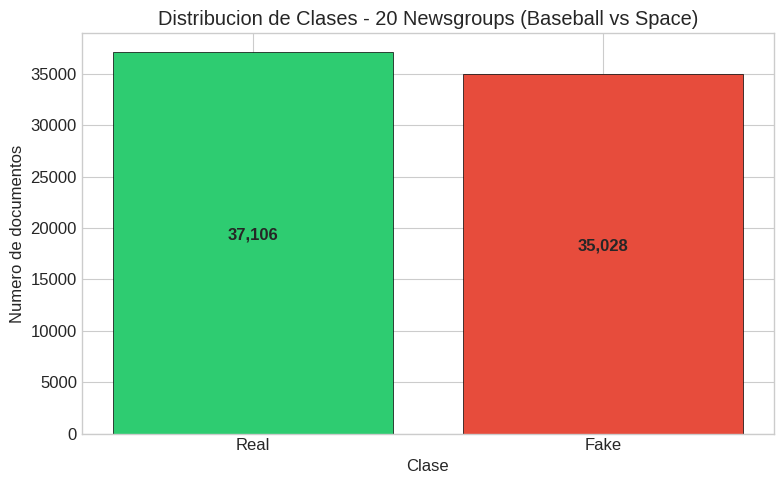

In [52]:
class_counts = df['label'].value_counts()

print(class_counts)
print('Distribucion de clases:')
for label, count in class_counts.items():
    name = class_names[label]
    print(f'  {name} (label={label}): {count:,} ({count/len(df)*100:.1f}%)')

# Grafico de barras
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [class_names[i] for i in class_counts.index],
    class_counts.values,
    color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5
)

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Clase')
ax.set_ylabel('Numero de documentos')
ax.set_title('Distribucion de Clases - 20 Newsgroups (Baseball vs Space)')
plt.tight_layout()
plt.show()

In [53]:
print("Imbalance Rate:", round(class_counts[1] / class_counts[0], 2))

Imbalance Rate: 1.06


El ratio de desbalance es menor a 1.5 y está bastante cercano a 1, por lo que realmente es muy ligero este desbalance.

# Distribución de Longitudes de Texto

In [54]:
# Titulo
# Calcular longitudes (en numero de palabras)
df['title_len'] = df['title'].apply(lambda x: len(str(x).split()))

# Estadisticas descriptivas
print('=== Longitud del TEXTO (en palabras) ===')
print(f"  Media:   {df['title_len'].mean():.1f}")
print(f"  Mediana: {df['title_len'].median():.1f}")
print(f"  Minimo:  {df['title_len'].min()}")
print(f"  Maximo:  {df['title_len'].max()}")

# Estadisticas por clase
print(f'\n=== Estadisticas por clase ===')
for label, name in class_names.items():
    subset = df[df['label'] == label]['title_len']
    print(f'  {name}: media={subset.mean():.1f}, mediana={subset.median():.1f}, '
          f'min={subset.min()}, max={subset.max()}')

=== Longitud del TEXTO (en palabras) ===
  Media:   12.2
  Mediana: 12.0
  Minimo:  1
  Maximo:  72

=== Estadisticas por clase ===
  Fake: media=11.0, mediana=11.0, min=2, max=30
  Real: media=13.3, mediana=13.0, min=1, max=72


In [55]:
# Texto
# Calcular longitudes (en numero de palabras)
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))

# Estadisticas descriptivas
print('=== Longitud del TEXTO (en palabras) ===')
print(f"  Media:   {df['text_len'].mean():.1f}")
print(f"  Mediana: {df['text_len'].median():.1f}")
print(f"  Minimo:  {df['text_len'].min()}")
print(f"  Maximo:  {df['text_len'].max()}")

# Estadisticas por clase
print(f'\n=== Estadisticas por clase ===')
for label, name in class_names.items():
    subset = df[df['label'] == label]['text_len']
    print(f'  {name}: media={subset.mean():.1f}, mediana={subset.median():.1f}, '
          f'min={subset.min()}, max={subset.max()}')

=== Longitud del TEXTO (en palabras) ===
  Media:   540.6
  Mediana: 398.0
  Minimo:  0
  Maximo:  24234

=== Estadisticas por clase ===
  Fake: media=577.6, mediana=427.0, min=0, max=14641
  Real: media=505.6, mediana=369.0, min=0, max=24234


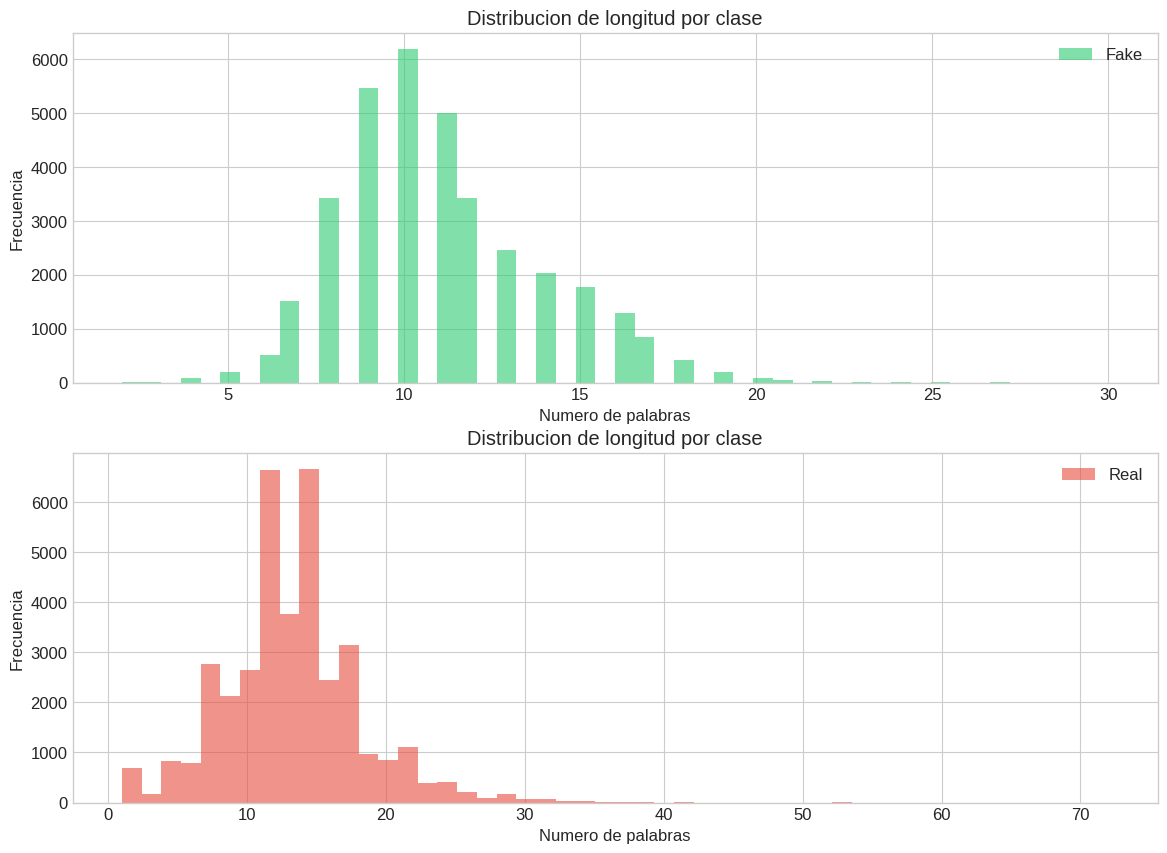

In [56]:
# Título
# Histogramas de longitudes por clase
fig, axes = plt.subplots(2,1,figsize=(14, 10))

# Histograma superpuesto
#for label, name in class_names.items():
#    subset = df[df['label'] == label]['text_len']
#    axes[0].hist(subset, bins=50, alpha=0.6, label=name,
#                 color='#2ecc71' if label == 0 else '#e74c3c')

subset = df[df['label'] == 0]['title_len']
axes[0].hist(subset, bins=50, alpha=0.6, label='Fake',color='#2ecc71')
axes[0].set_xlabel('Numero de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribucion de longitud por clase')
axes[0].legend()

subset = df[df['label'] == 1]['title_len']
axes[1].hist(subset, bins=50, alpha=0.6, label='Real',color='#e74c3c')
axes[1].set_xlabel('Numero de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de longitud por clase')
axes[1].legend()

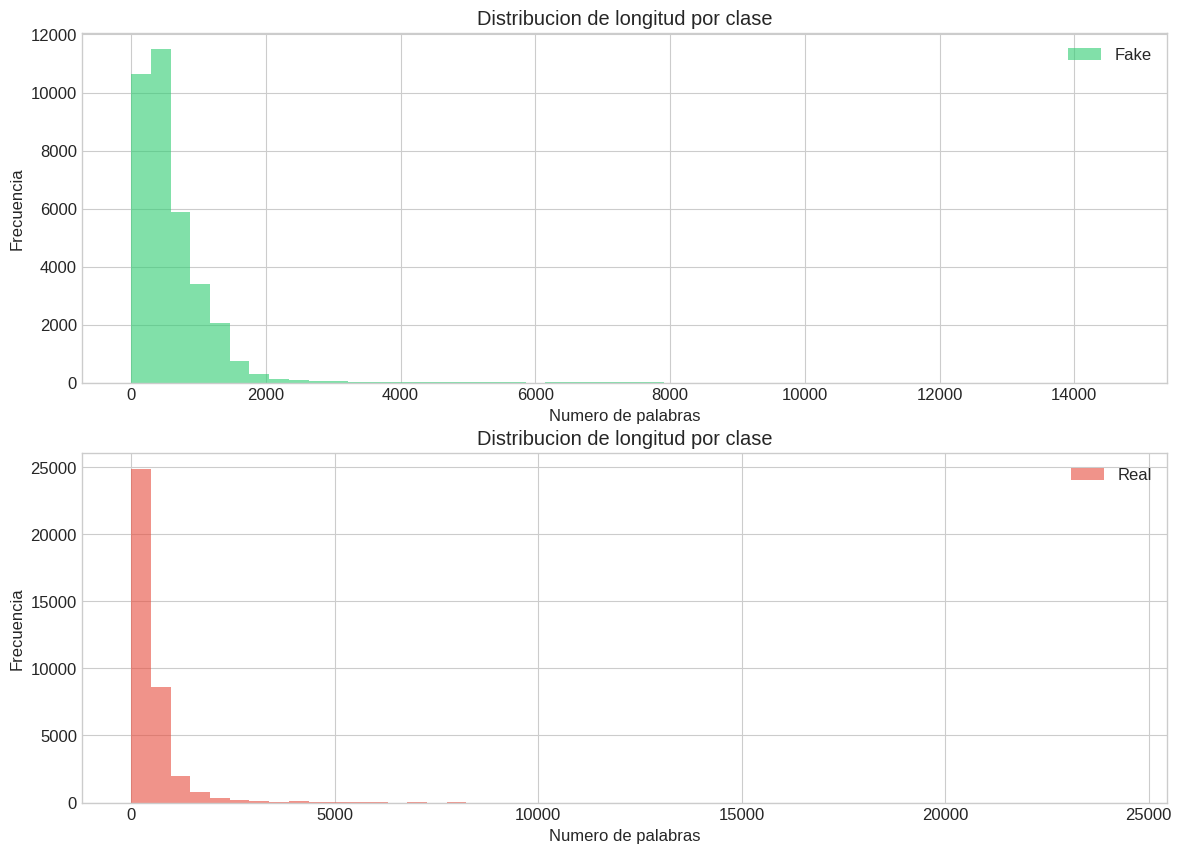

In [57]:
# Texto
# Histogramas de longitudes por clase
fig, axes = plt.subplots(2,1,figsize=(14, 10))

# Histograma superpuesto
#for label, name in class_names.items():
#    subset = df[df['label'] == label]['text_len']
#    axes[0].hist(subset, bins=50, alpha=0.6, label=name,
#                 color='#2ecc71' if label == 0 else '#e74c3c')

subset = df[df['label'] == 0]['text_len']
axes[0].hist(subset, bins=50, alpha=0.6, label='Fake',color='#2ecc71')
axes[0].set_xlabel('Numero de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribucion de longitud por clase')
axes[0].legend()

subset = df[df['label'] == 1]['text_len']
axes[1].hist(subset, bins=50, alpha=0.6, label='Real',color='#e74c3c')
axes[1].set_xlabel('Numero de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de longitud por clase')
axes[1].legend()

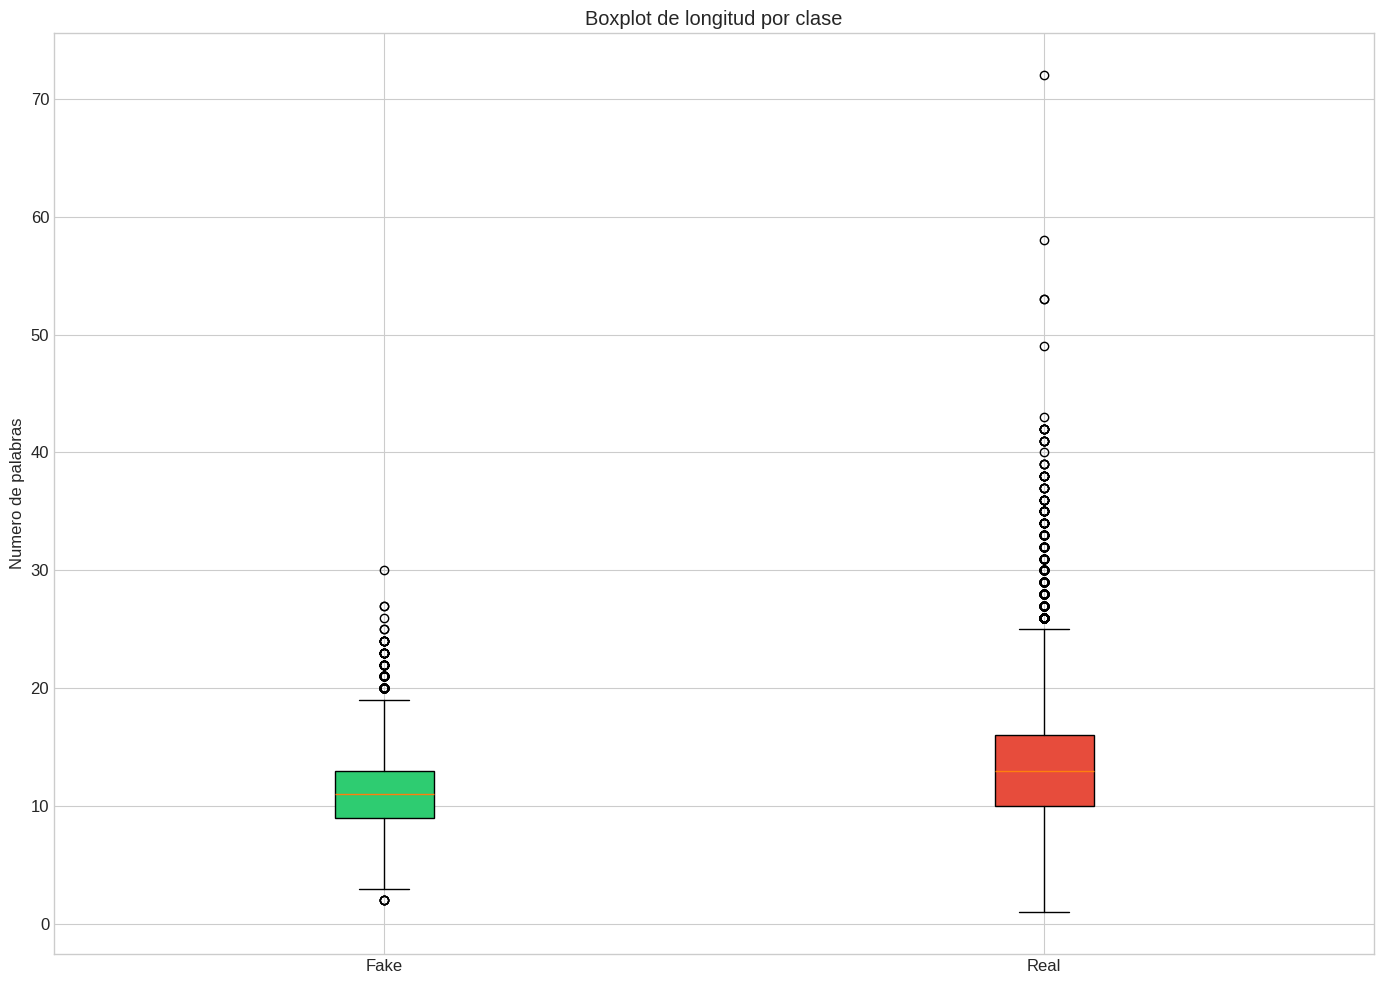

In [58]:
# Title
fig, axes = plt.subplots(figsize=(14, 10))

data_by_class = [df[df['label'] == l]['title_len'].values for l in class_names]
bp = axes.boxplot(data_by_class, labels=list(class_names.values()),
                     patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes.set_ylabel('Numero de palabras')
axes.set_title('Boxplot de longitud por clase')

plt.tight_layout()
plt.show()

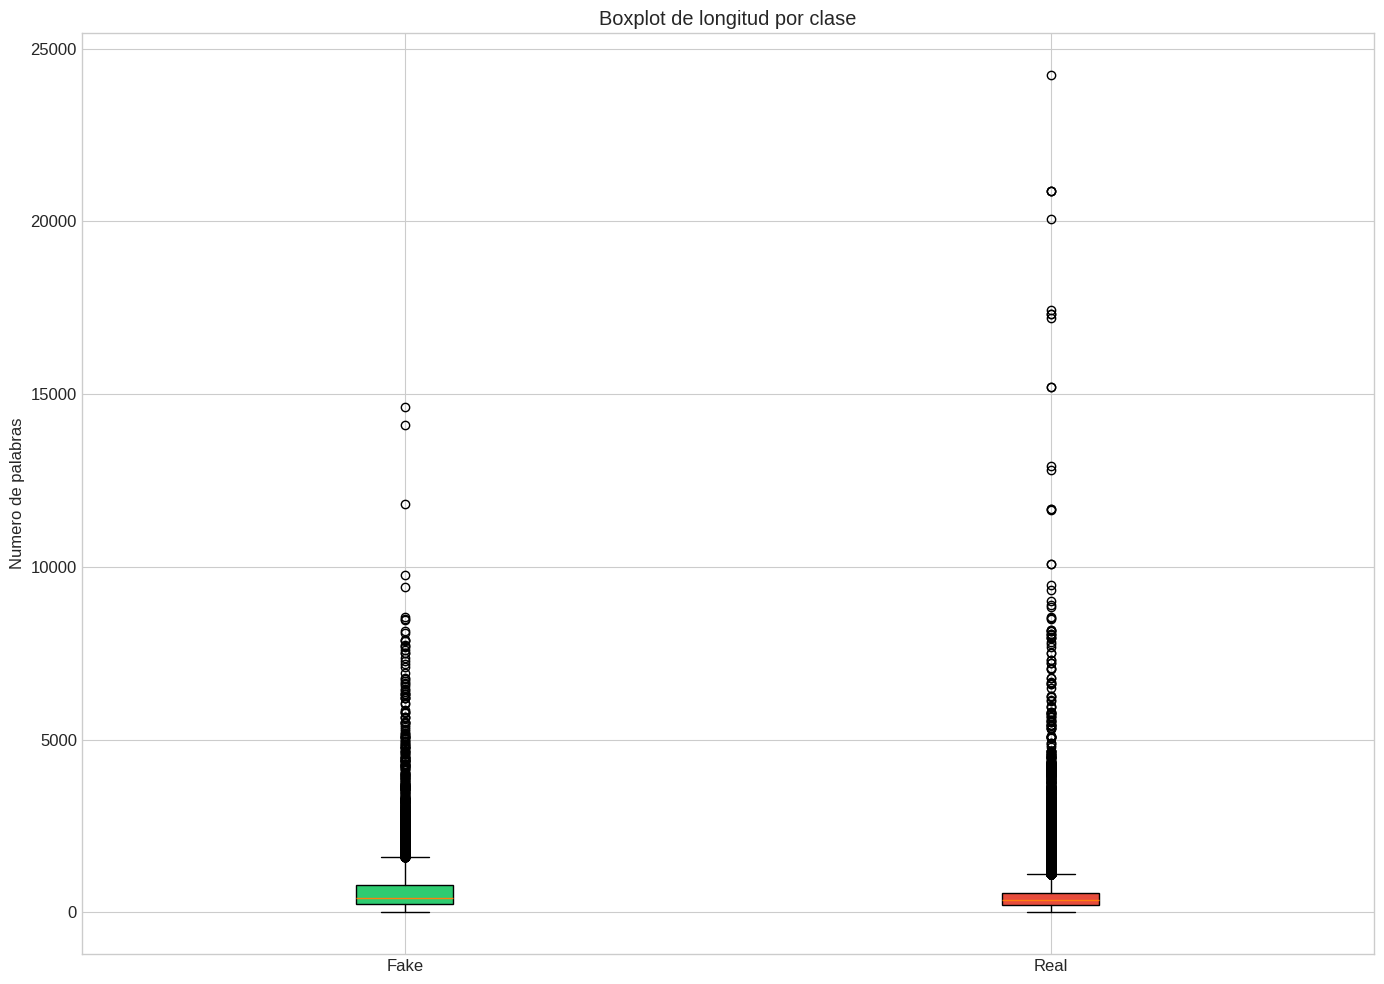

In [59]:
# Texto
fig, axes = plt.subplots(figsize=(14, 10))

data_by_class = [df[df['label'] == l]['text_len'].values for l in class_names]
bp = axes.boxplot(data_by_class, labels=list(class_names.values()),
                     patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes.set_ylabel('Numero de palabras')
axes.set_title('Boxplot de longitud por clase')

plt.tight_layout()
plt.show()

In [60]:
display(df.describe())
for col in ['title_len', 'text_len']:
    print(f'\n=== {col} ===')
    print(f'  Media:   {df[col].mean():.1f}')
    print(f'  Mediana: {df[col].median():.1f}')
    print(f'  Minimo:  {df[col].min()}')
    print(f'  Maximo:  {df[col].max()}')

,label,title_len,text_len
count,72134.000000,72134.000000,72134.000000
mean,0.514404,12.181052,540.551474
std,0.499796,4.234335,625.399281
min,0.000000,1.000000,0.000000
25%,0.000000,9.000000,227.000000
50%,1.000000,12.000000,398.000000
75%,1.000000,14.000000,667.000000
max,1.000000,72.000000,24234.000000



=== title_len ===
  Media:   12.2
  Mediana: 12.0
  Minimo:  1
  Maximo:  72

=== text_len ===
  Media:   540.6
  Mediana: 398.0
  Minimo:  0
  Maximo:  24234


In [61]:
len(df[(df['label'] == 0) & (df['text_len'] > 200)])/len(df)

0.38135969168491973

In [62]:
len(df[(df['label'] == 1) & (df['text_len'] > 200)])/len(df)

0.39680317187456676

In [63]:
round(0.38135969+ 0.39680317, 8)

0.77816286

**Reflexión:**
- ¿Hay diferencias de longitud entre documentos fake y real?
  -  Sí, ya que, aunque la media y mediana no cambian mucho, el máximo de cada uno, respectivamente, sí es bastante diferente; las noticias reales son más largas por casi 10000 palabras más.
- Si usaramos `max_len=200` tokens, ¿qué porcentaje de textos se truncarían?
  -  Para las noticias falsas, sería de 38.135969% y para las reales serían de 39.680317%, en total: 77.816286%.

# Detección y Manejo de Valores Nulos

In [64]:
# Deteccion de valores nulos
print('Valores nulos por columna:')
null_counts = df.isnull().sum()
print(null_counts)
print(f'\nTotal de filas con al menos un nulo: {df.isnull().any(axis=1).sum()}')
print(f'Porcentaje del dataset: {df.isnull().any(axis=1).sum() / len(df) * 100:.2f}%')

# Revisar si hay textos vacios (no NaN, pero sin contenido)
empty_texts = (df['text'].str.strip() == '').sum()
print(f'\nTextos vacios (cadena vacia): {empty_texts}')

Valores nulos por columna:
title        558
text          39
label          0
title_len      0
text_len       0
dtype: int64

Total de filas con al menos un nulo: 597
Porcentaje del dataset: 0.83%

Textos vacios (cadena vacia): 744


In [65]:
# Título
# Estrategia: si hay nulos o textos vacios, los manejamos
rows_before = len(df)

# Rellenar nulos con cadena vacia
df['title'] = df['title'].fillna('')

# Eliminar filas con texto vacio (no aportan informacion)
df = df[df['title'].str.strip().str.len() > 0].reset_index(drop=True)

rows_after = len(df)
print(f'Filas antes: {rows_before:,}')
print(f'Filas despues: {rows_after:,}')
print(f'Filas eliminadas: {rows_before - rows_after:,}')
print(f'Nulos restantes: {df.isnull().sum().sum()}')

Filas antes: 72,134
Filas despues: 71,576
Filas eliminadas: 558
Nulos restantes: 39


In [66]:
# Texto
# Estrategia: si hay nulos o textos vacios, los manejamos
rows_before = len(df)

# Rellenar nulos con cadena vacia
df['text'] = df['text'].fillna('')

# Eliminar filas con texto vacio (no aportan informacion)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)

rows_after = len(df)
print(f'Filas antes: {rows_before:,}')
print(f'Filas despues: {rows_after:,}')
print(f'Filas eliminadas: {rows_before - rows_after:,}')
print(f'Nulos restantes: {df.isnull().sum().sum()}')

Filas antes: 71,576
Filas despues: 70,793
Filas eliminadas: 783
Nulos restantes: 0


Se decidió eliminar las filas con valores nulos, ya que aplicar técnicas alternativas como la imputación no es viable en este contexto: en el caso particular de texto, generar contenido sintético compromete el realismo de los datos. Del mismo modo, se eliminaron las filas con texto o título vacíos (`text = ""`), pues no solo no aportan información útil al modelo, sino que una noticia sin contenido hace imposible determinar su veracidad y, más fundamentalmente, impide tratarla como una noticia en absoluto.

# Detección y Manejo de Duplicados

In [67]:
# Título
duplicates = df.duplicated(subset=['title'], keep='first')
n_duplicates = duplicates.sum()
print(f'Filas duplicadas encontradas: {n_duplicates:,}')
print(f'Porcentaje del dataset: {n_duplicates / len(df) * 100:.2f}%')

if n_duplicates > 0:
    print(f'\nEjemplo de fila duplicada:')
    dup_idx = duplicates[duplicates].index[0]
    print(f'  Título: {df.loc[dup_idx, "title"][:100]}...')
    print(f'  Clase: {class_names[df.loc[dup_idx, "label"]]}')

Filas duplicadas encontradas: 9,010
Porcentaje del dataset: 12.73%

Ejemplo de fila duplicada:
  Título: Just Weeks After Obama’s Executive Order on Catastrophic Space Weather Events, a Coronal Mass Ejecti...
  Clase: Real


In [68]:
#Título
# Eliminar duplicados
rows_before = len(df)
df = df.drop_duplicates(subset=['title'], keep='first').reset_index(drop=True)
rows_after = len(df)

print(f'Filas antes: {rows_before:,}')
print(f'Filas despues: {rows_after:,}')
print(f'Filas eliminadas: {rows_before - rows_after:,}')

# Verificar impacto en balance de clases
print(f'\nDistribucion de clases despues de eliminar duplicados:')
for label, count in df['label'].value_counts().items():
    name = class_names[label]
    print(f'  {name}: {count:,} ({count/len(df)*100:.1f}%)')

Filas antes: 70,793
Filas despues: 61,783
Filas eliminadas: 9,010

Distribucion de clases despues de eliminar duplicados:
  Fake: 34,406 (55.7%)
  Real: 27,377 (44.3%)


In [69]:
# Texto
# Deteccion de duplicados
duplicates = df.duplicated(subset=['text'], keep='first')
n_duplicates = duplicates.sum()
print(f'Filas duplicadas encontradas: {n_duplicates:,}')
print(f'Porcentaje del dataset: {n_duplicates / len(df) * 100:.2f}%')

if n_duplicates > 0:
    print(f'\nEjemplo de fila duplicada:')
    dup_idx = duplicates[duplicates].index[0]
    print(f'  Texto: {df.loc[dup_idx, "text"][:100]}...')
    print(f'  Clase: {class_names[df.loc[dup_idx, "label"]]}')

Filas duplicadas encontradas: 389
Porcentaje del dataset: 0.63%

Ejemplo de fila duplicada:
  Texto: Killing Obama administration rules, dismantling Obamacare and pushing through tax reform are on the ...
  Clase: Fake


In [70]:
# Texto
# Eliminar duplicados
rows_before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
rows_after = len(df)

print(f'Filas antes: {rows_before:,}')
print(f'Filas despues: {rows_after:,}')
print(f'Filas eliminadas: {rows_before - rows_after:,}')

# Verificar impacto en balance de clases
print(f'\nDistribucion de clases despues de eliminar duplicados:')
for label, count in df['label'].value_counts().items():
    name = class_names[label]
    print(f'  {name}: {count:,} ({count/len(df)*100:.1f}%)')

Filas antes: 61,783
Filas despues: 61,394
Filas eliminadas: 389

Distribucion de clases despues de eliminar duplicados:
  Fake: 34,237 (55.8%)
  Real: 27,157 (44.2%)


Distribucion de clases:
  Fake (label=0): 34,237 (55.8%)
  Real (label=1): 27,157 (44.2%)


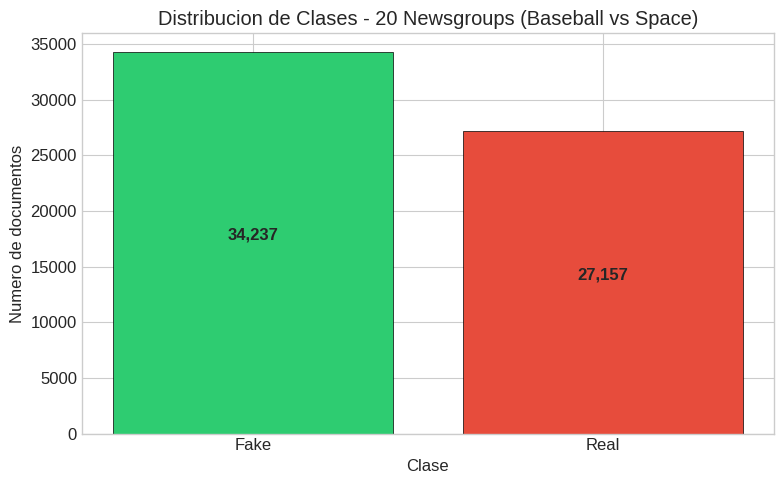

In [71]:
# Distribucion de clases
class_counts = df['label'].value_counts()

print('Distribucion de clases:')
for label, count in class_counts.items():
    name = class_names[label]
    print(f'  {name} (label={label}): {count:,} ({count/len(df)*100:.1f}%)')

# Grafico de barras
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [class_names[i] for i in class_counts.index],
    class_counts.values,
    color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5
)

for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
            f'{count:,}', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Clase')
ax.set_ylabel('Numero de documentos')
ax.set_title('Distribucion de Clases - 20 Newsgroups (Baseball vs Space)')
plt.tight_layout()
plt.show()

In [72]:
print("Imbalance Ratio:", round(class_counts[0] / class_counts[1], 2))

Imbalance Ratio: 1.26


El desbalance de clase ya es un poco más alto en esta ocasión, pero sigue siendo moderado, `IR < 1.5`.

# Carga del DF

In [73]:
outpute_path = "/content/drive/MyDrive/ModeladoPredictivo2026/data/cleaned_df.csv"

In [74]:
cleaned_df = df.copy()
cleaned_df.to_csv(outpute_path, index=False)

# Nubes de Palabras por Clase

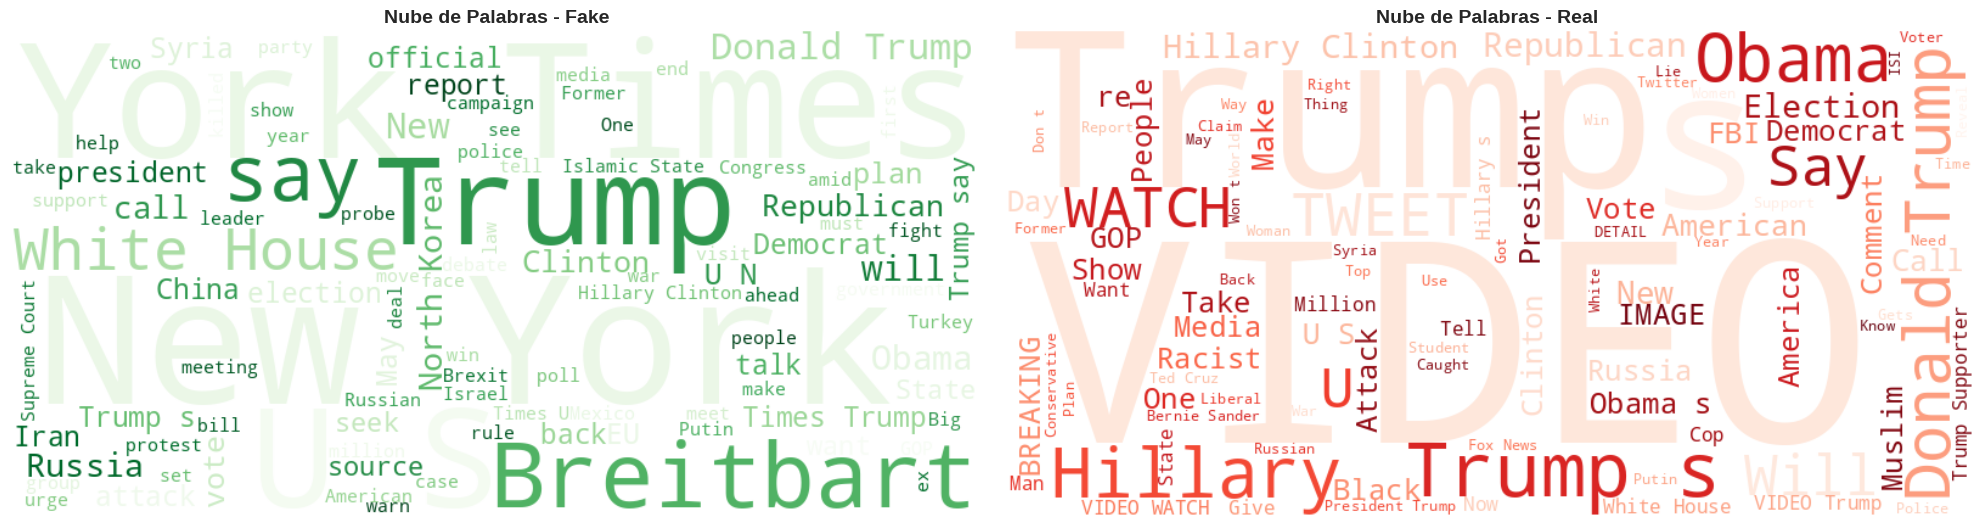

In [75]:
# Título
# Nubes de palabras
fig, axes = plt.subplots(1, 2, figsize=(20, 15))

colors_map = {0: 'Greens', 1: 'Reds'}
for idx, (label, name) in enumerate(class_names.items()):
    title = ' '.join(df[df['label'] == label]['title'].astype(str).values)
    wordcloud = WordCloud(
        width=800, height=400,
        max_words=100,
        background_color='white',
        colormap=colors_map[label],
        random_state=42
    ).generate(title)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Nube de Palabras - {name}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

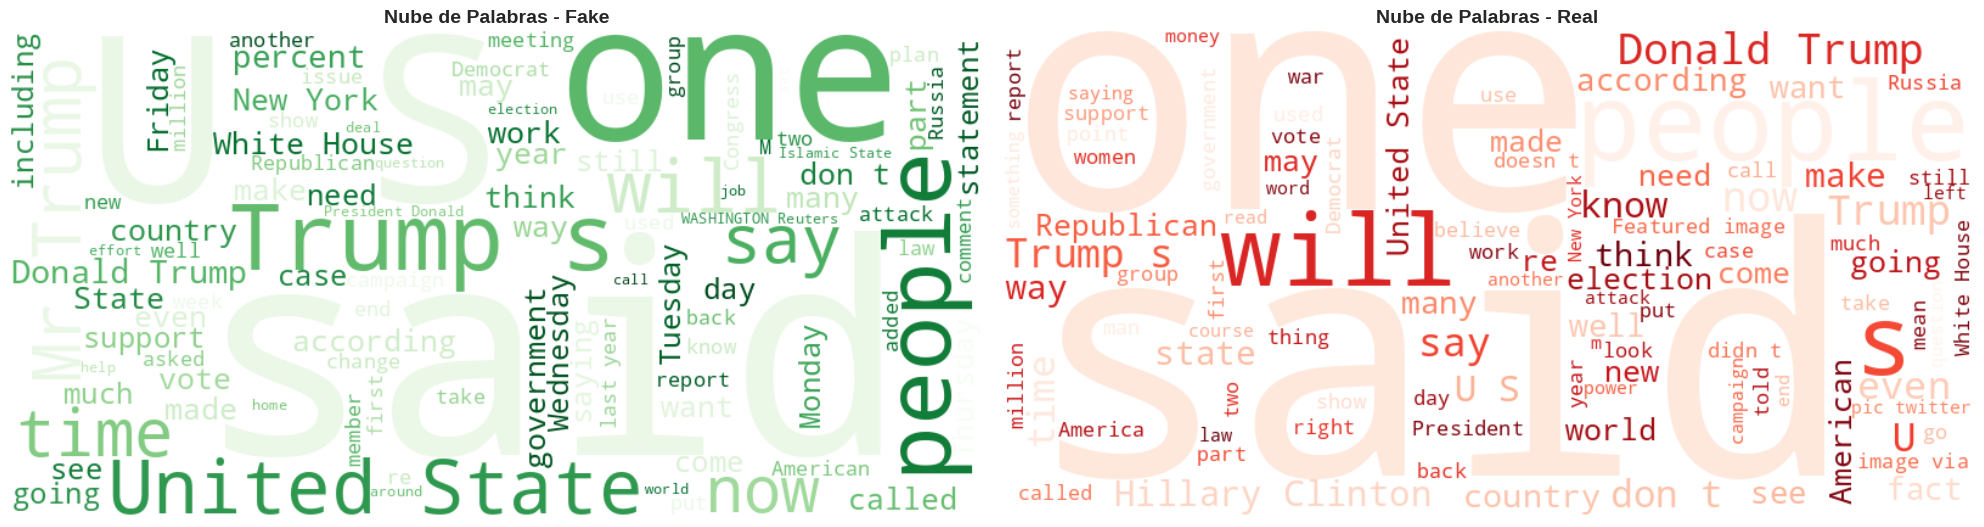

In [76]:
# Texto
# Nubes de palabras
fig, axes = plt.subplots(1, 2, figsize=(20, 15))

colors_map = {0: 'Greens', 1: 'Reds'}
for idx, (label, name) in enumerate(class_names.items()):
    text = ' '.join(df[df['label'] == label]['text'].astype(str).values)
    wordcloud = WordCloud(
        width=800, height=400,
        max_words=100,
        background_color='white',
        colormap=colors_map[label],
        random_state=42
    ).generate(text)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Nube de Palabras - {name}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

La diferencia más notable es que las noticias reales mencionan con alta frecuencia la palabra `Video`, lo cual probablemente se deba a que la evidencia audiovisual es uno de los factores que distingue una noticia real de una falsa.

# Top Palabras más frecuentes por clase

In [77]:
from collections import Counter

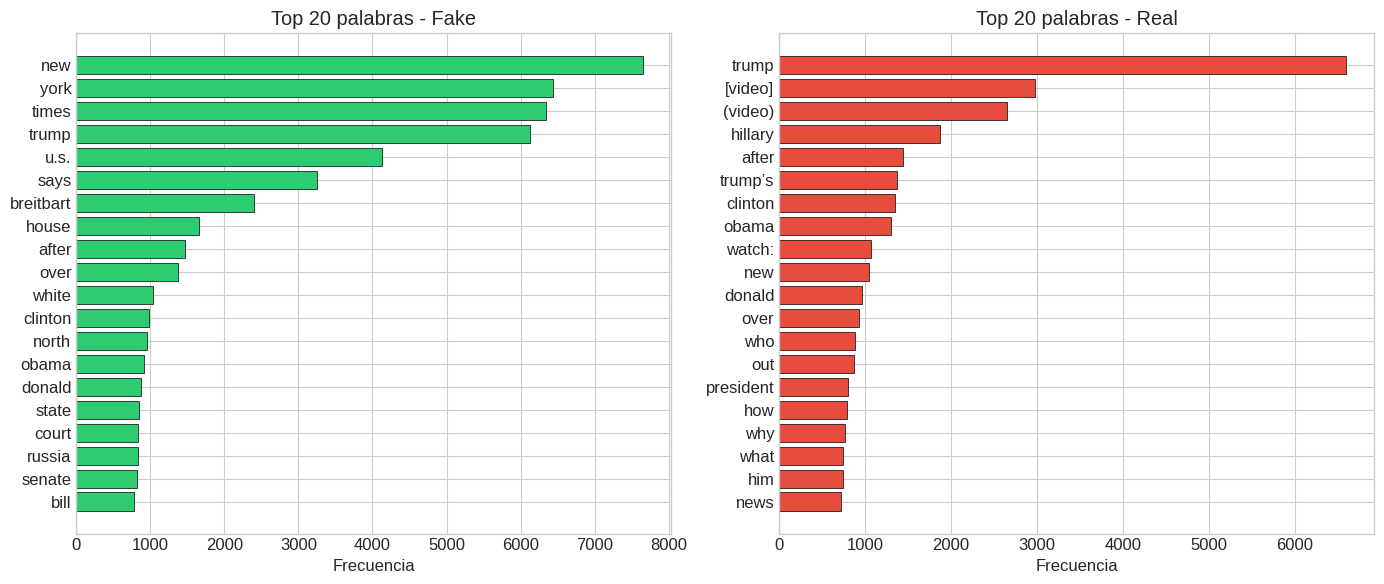

In [78]:
# Título
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (label, name) in enumerate(class_names.items()):
    # Contar todas las palabras de la clase
    all_text = ' '.join(df[df['label'] == label]['title'].str.lower().values)
    word_counts = Counter(all_text.split())

    # Top 20 (excluyendo stopwords comunes)
    stopwords = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been',
                 'to', 'of', 'in', 'for', 'and', 'on', 'that', 'it', 'with',
                 'as', 'at', 'by', 'from', 'or', 'this', 'but', 'not', 'have',
                 'has', 'had', 'i', 'he', 'she', 'they', 'we', 'you', 'my',
                 'his', 'her', 'its', 'our', 'their', 'if', 'do', 'did', 'would',
                 'will', 'can', 'just', 'about', 'so', 'than', 'no', 'all'}
    filtered = {w: c for w, c in word_counts.items()
                if w not in stopwords and len(w) > 2}
    top_20 = sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:20]
    words, counts = zip(*top_20)

    color = '#2ecc71' if label == 0 else '#e74c3c'
    axes[idx].barh(range(len(words)), counts[::-1], color=color, edgecolor='black', linewidth=0.5)
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words[::-1])
    axes[idx].set_xlabel('Frecuencia')
    axes[idx].set_title(f'Top 20 palabras - {name}')

plt.tight_layout()
plt.show()

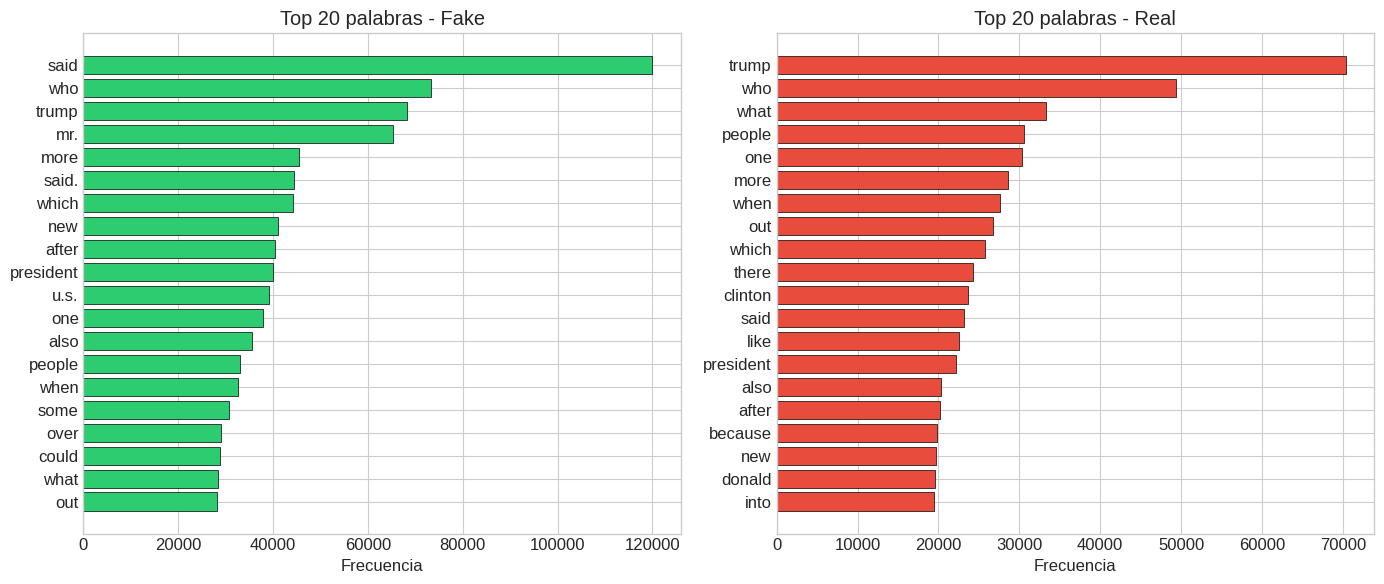

In [79]:
# Texto
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (label, name) in enumerate(class_names.items()):
    # Contar todas las palabras de la clase
    all_text = ' '.join(df[df['label'] == label]['text'].str.lower().values)
    word_counts = Counter(all_text.split())

    # Top 20 (excluyendo stopwords comunes)
    stopwords = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been',
                 'to', 'of', 'in', 'for', 'and', 'on', 'that', 'it', 'with',
                 'as', 'at', 'by', 'from', 'or', 'this', 'but', 'not', 'have',
                 'has', 'had', 'i', 'he', 'she', 'they', 'we', 'you', 'my',
                 'his', 'her', 'its', 'our', 'their', 'if', 'do', 'did', 'would',
                 'will', 'can', 'just', 'about', 'so', 'than', 'no', 'all'}
    filtered = {w: c for w, c in word_counts.items()
                if w not in stopwords and len(w) > 2}
    top_20 = sorted(filtered.items(), key=lambda x: x[1], reverse=True)[:20]
    words, counts = zip(*top_20)

    color = '#2ecc71' if label == 0 else '#e74c3c'
    axes[idx].barh(range(len(words)), counts[::-1], color=color, edgecolor='black', linewidth=0.5)
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words[::-1])
    axes[idx].set_xlabel('Frecuencia')
    axes[idx].set_title(f'Top 20 palabras - {name}')

plt.tight_layout()
plt.show()

# Preguntas de Reflexion sobre el Analisis Exploratorio de Datos

**1.** ¿Por que es importante realizar un EDA antes de entrenar cualquier modelo de machine learning? ¿Que problemas podrian surgir si nos saltamos este paso?

**2.** Al analizar la distribucion de clases, ¿encontraste que el dataset esta balanceado o desbalanceado? ¿Como afectaria un desbalance severo (por ejemplo 90/10) al entrenamiento de un clasificador? ¿Que tecnicas conoces para mitigarlo?

**3.** Observando las distribuciones de longitud del texto, ¿las noticias falsas tienden a ser mas largas o mas cortas que las reales? ¿Que hipotesis podrias formular sobre por que existe esa diferencia?

**4.** Si eligieras un `max_len=200` palabras para truncar los textos antes de alimentar una red neuronal, ¿que porcentaje de informacion se perderia? ¿Como decidiras el valor optimo de `max_len` considerando el trade-off entre informacion y costo computacional?

**5.** ¿Que estrategia elegiste para manejar los valores nulos y por que? ¿En que escenarios seria mejor rellenar con un texto especial en lugar de eliminar las filas? ¿Y viceversa?

**6.** El dataset WELFake tenia aproximadamente un 11.7% de duplicados. ¿Por que es critico eliminarlos antes de dividir en conjuntos de entrenamiento y prueba? ¿Que sucederia con las metricas de evaluacion si no lo hicieramos?

**7.** ¿Que limitaciones tiene el EDA que realizamos? Menciona al menos dos aspectos del texto que NO exploramos y que podrian ser relevantes para la clasificacion (por ejemplo: estructura de oraciones, uso de signos de puntuacion, sentimiento, etc.).

**8.** Reflexiona sobre el impacto social de las noticias falsas. ¿Por que es importante que como ingenieros desarrollemos herramientas para detectarlas? ¿Que responsabilidad etica conlleva construir un clasificador de este tipo? ¿Que sucede si el modelo comete errores (falsos positivos vs falsos negativos)?

**9.** Considerando todo lo aprendido en este EDA, ¿que caracteristicas (features) del texto crees que seran mas utiles para que un modelo distinga entre noticias reales y falsas? ¿Crees que el titulo, el cuerpo del texto, o ambos seran mas informativos? Justifica tu respuesta con base en los datos explorados.

### Escribe tus respuestas aqui:

**R1.** El EDA permite conocer la naturaleza real del dataset antes de tomar decisiones de modelado, además de detectar diferentes elementos que pueden perjudicar al modelo, como los datos nulos, duplicados, el desbalance de clases y los outliers.

**R2.** El dataset no está desbalanceado: en su forma original tenía apenas un ligero desbalance, y tras eliminar los duplicados su Imbalance Ratio subió a 1.26, lo cual, aunque es más moderado, sigue siendo aceptable.

**R3.** Las noticias reales son más largas que las falsas por casi 10,000 palabras. Esto posiblemente se debe a que una noticia falsa requiere mayor esfuerzo para parecer creíble, por lo que es más difícil mantener coherencia y lógica en un texto largo que en uno corto. Además, el propósito de las noticias falsas suele ser generar un impacto fuerte (ya sea para dañar una reputación, causar caos o simplemente amarillismo), por lo que importa más cómo se narra el mensaje que su extensión. Las noticias reales, en cambio, buscan narrar los eventos con el mayor detalle posible, incluyendo contexto, citas de otras fuentes e incluso noticias relacionadas, lo que naturalmente produce textos más largos cuando los eventos son complejos.

**R4.** Con `max_len=200`, se truncaría aproximadamente el 77.82% de los textos en total (38.14% de noticias falsas y 39.68% de noticias reales). Para elegir un valor óptimo habría que graficar la distribución acumulada de longitudes y encontrar un percentil razonable, como el 75 o el 90, que cubra la mayoría de los textos. También se puede considerar un enfoque basado en outliers para distinguir entre noticias de longitud común y casos más extremos.

**R5.** Se eligió eliminar las filas con nulos y textos vacíos porque la imputación no es viable para datos textuales: generar texto sintético introduciría ruido y comprometería el realismo del corpus. Sería preferible rellenar con un token especial cuando la ausencia misma sea una señal informativa para el modelo, y eliminar cuando los nulos sean escasos y no aporten ninguna señal, como ocurre en este dataset.

**R6.** Si no se eliminan los duplicados antes de dividir el dataset, la red neuronal puede aprender casos muy específicos y sesgarse hacia esos patrones, además de que ejemplos repetidos en train y test inflan artificialmente las métricas de evaluación, haciendo que el modelo parezca más generalizable de lo que realmente es.

**R7.** Dos limitaciones relevantes del EDA realizado son: en primer lugar, no se exploró el sentimiento o tono emocional del texto, que podría ser un discriminador importante dado que las noticias falsas tienden a usar lenguaje más alarmista o cargado emocionalmente. En segundo lugar, no se analizó la estructura lingüística, como el uso de signos de exclamación, mayúsculas o la complejidad sintáctica de las oraciones, patrones que suelen diferir entre la escritura periodística formal y el contenido fabricado.

**R8.** Las noticias falsas tienen consecuencias concretas: influyen en decisiones políticas, generan pánico y erosionan la confianza en las instituciones. Desarrollar herramientas de detección es una responsabilidad tanto técnica como cívica. La carga ética es alta: un falso positivo (clasificar una noticia real como falsa) puede silenciar periodismo legítimo y constituir censura; un falso negativo (clasificar desinformación como real) permite que el daño se propague. Por eso la elección de la métrica de optimización no es neutral: dependiendo del contexto, podría priorizarse minimizar los falsos positivos (proteger la libertad de prensa) o los falsos negativos (proteger a la audiencia).

**R9.** Tanto en noticias falsas como reales se emplea un vocabulario con una distribución bastante similar, por lo que es posible que sean otros factores los que determinen si una noticia es falsa o no. El único detalle particular destacable es la palabra `Video` , que aparece con una frecuencia notablemente mayor en las noticias reales, lo cual sugiere que la presencia de evidencia audiovisual podría ser una señal relevante para el clasificador.